<a href="https://colab.research.google.com/github/Israel395/Arvore-decisao-IA/blob/main/Arvore_decisao_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importação da biblioteca pandas, para ler o csv
import pandas as pd
# importação da biblioteca matplot para criação de grafico e visualização de dados
import matplotlib.pyplot as plt
import numpy as np
import itertools
import os

In [ ]:
#carregando o dataset
df=pd.read_csv("./diabetes.csv")

# Retorne as primeiras 5 linhas do dataframe
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# variavel feature. outcome = Resultado
# logo retira-se o resultado e é colocado todos os outros campos na varivael x
x=df.drop(['Outcome'], axis=1)
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [ ]:
# e então pega-se a variavel y e atribui a ela os resultados
y=df.Outcome
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [ ]:
from sklearn.tree import DecisionTreeClassifier # Importação da função da arvore de decisão
from sklearn.model_selection import train_test_split # Importação da função que divide os dados em dados de treino e de teste
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [ ]:
# Criação de um objeto de arvore de decisão
model = DecisionTreeClassifier()

# Treinamento dos dados
model = model.fit(x_train,y_train)

# Prever a resposta do conjunto de dados de teste
y_pred = model.predict(x_test)

In [ ]:
# Avaliação usando o score de precisão
from sklearn import metrics #Importação de um modulo de uma metrica de scikit-learn para cálculos precisos

# precisão da predição com os dados de teste
print("Precisão:",metrics.accuracy_score(y_test, y_pred)*100)

Precisão: 68.83116883116884


Matriz de Confusão sem normalizacão 
[[75 24]
 [24 31]]


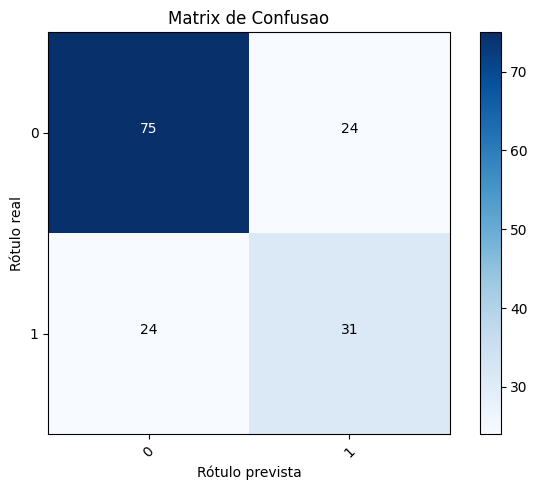

In [ ]:
# Avaliação usando matriz de confusão
from sklearn.metrics import confusion_matrix

nome_classes = model.classes_
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Matriz de Confusão Normalizada")
    else:
        print('Matriz de Confusão sem normalizacão ')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Rótulo real')
    plt.xlabel('Rótulo prevista')

matrix_confusao = confusion_matrix(y_test,y_pred)
plt.figure()
plot_confusion_matrix(matrix_confusao, classes=nome_classes,
                      title='Matrix de Confusao')



In [ ]:
#Importarção módulos para visualizar árvores de decisão
# Esta função gera uma representação grafica da árvore de decisão
from sklearn.tree import export_graphviz

# biblioteca para ler e escrever "string"
from io import StringIO
from IPython.display import Image

# que fornece uma interface Python para o Graphviz
import pydotplus

In [ ]:
features=x.columns
features

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

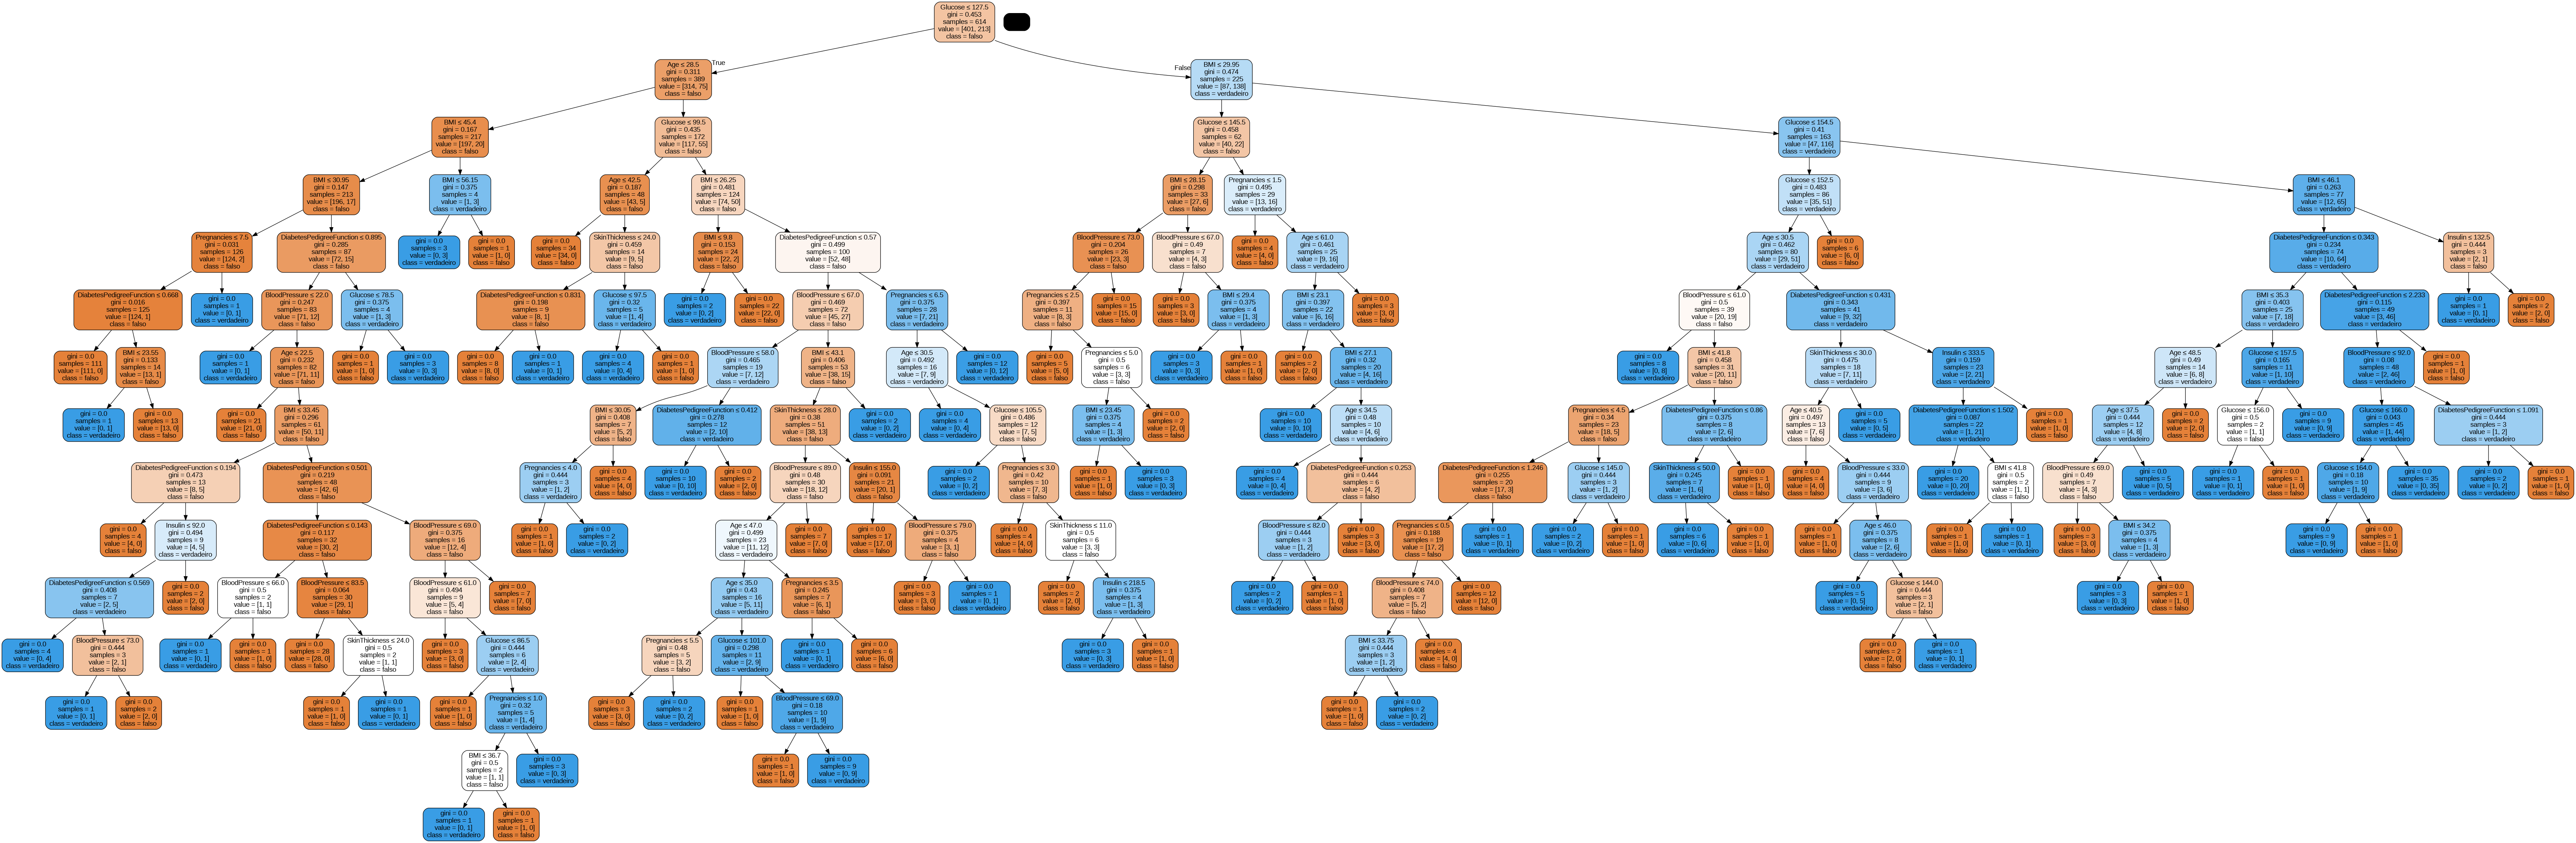

In [ ]:
# MONTAR A IMAGEM DA ÁRVORE
dot_data = StringIO()

#out_file: Identificador ou nome do arquivo de saída. Se , o resultado é retornado como uma cadeia de caracteres.
# filled: pinta caixas para indicar a classe majoritária para classificação, extremidade dos valores para regressão ou pureza da caixa para varias sidas.
# rounded: desenhe caixas com cantos arredondados
# special_characters: ignora caracteres especiais
export_graphviz(model, out_file=dot_data,filled=True, rounded=True,special_characters=True,feature_names = features,class_names=['falso','verdadeiro'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes_set.png')
Image(graph.create_png())

In [ ]:
# Criação de objeto da árvore de decisão
model = DecisionTreeClassifier(criterion="entropy", max_depth=6)

# Treinamento da arvore
model = model.fit(x_train,y_train)

#Previzão da resposta do conjunto de dados de teste
y_pred = model.predict(x_test)

# Precisão do modelo
print("Precisão:",metrics.accuracy_score(y_test, y_pred)*100)

Precisão: 79.22077922077922


The classification rate increased to 79.87%, which is better accuracy than the previous model.



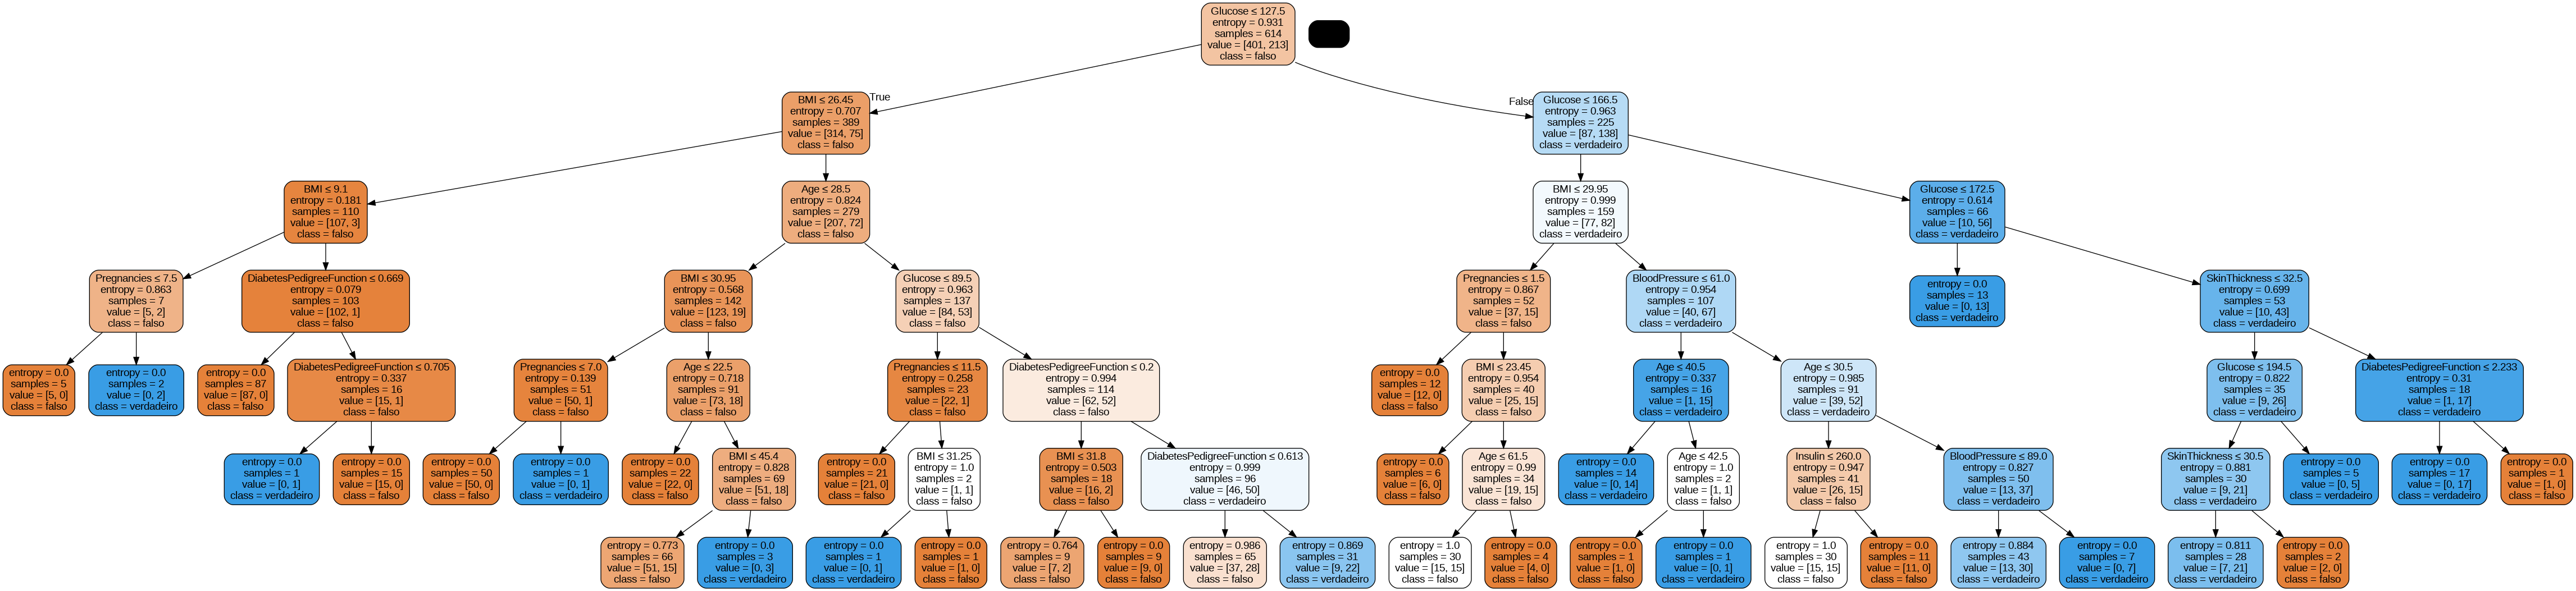

In [ ]:
#uma visualização melhor da arvore de decisão acima
from io import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(model, out_file=dot_data,filled=True, rounded=True,special_characters=True, feature_names = features,class_names=['falso','verdadeiro'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('diabetes_set.png')
Image(graph.create_png())